# 18. 중간지대 4품목 전용 모델

## Overview

14번에서 **중간지대 4품목**(상추·얼갈이배추·풋고추·배추)이 가장 유망하다고
나왔습니다. 저장이 되면서도(10~30일) 벌 것이 있는 구간입니다.

- 14번: 다 넣으면 창고에 넣은 물량 대비 **8.7%**
- 15번: 확신하는 날만 고르면 **16.2%**
- 17번: 품목당 **연 51일**(주 1회꼴)로 운영 가능, 적중률 **77.8%**

**그런데 지금 모델은 19품목을 한꺼번에 학습합니다.** 피마늘·생강처럼 성격이
전혀 다른 품목까지 같은 모델이 배웁니다. **이 넷만 따로 학습하면 더 나을까요.**

## 미리 의심할 것

16번에서 **학습 품목을 6 → 19개로 늘려도 기존 6품목 성적은 안 올랐습니다**
(-0.63%p, 노이즈 이내). 반대 방향(19 → 4)도 차이가 없을 가능성이 큽니다.

그리고 품목이 4개로 줄면 **노이즈 플로어가 넓어집니다**(교훈 7). 16번에서
6품목 기준이 ±1.15%p 였으니 여기서는 더 넓을 것입니다. **그것부터 재고
시작합니다.**

## 목차

1. 준비
2. 가설
3. 노이즈 플로어 재기 (4품목 기준)
4. 세 가지 학습 방식 비교
5. 운영 지표로 환산
6. 결론

> ## ⚠️ 정정 주의 (21번)
>
> **아래 "C 는 다른 자리를 차지한다"와 "창고비 5.48% 에서 갈린다"는 취소합니다.**
>
> C(품목별 개별 모델)가 총액으로 더 번 것은 **커버리지가 두 배였기 때문**입니다.
> C 는 `item_code` 가 없어 확률이 넓게 퍼져 저절로 73% 를 덮었고, A 는 37% 만
> 덮은 채로 비교됐습니다.
>
> 21번에서 **커버리지를 맞춰** 다시 재보니 일관된 우열이 없습니다: 적중률은 두
> 지점에서 C 가 지고, 창고비 한도는 세 지점에서 C 가 이기며, 나머지는 전부
> 노이즈 이내입니다. 부호가 커버리지마다 뒤집힙니다.
>
> **A 도 임계값을 낮추면 73% 를 덮습니다.** 그렇게 맞추면 C 가 주는 게 없습니다.
> **커버리지를 정하는 문제이지 모델 구조를 고르는 문제가 아니었습니다.**
>
> **유지되는 결론**: 전용 모델·품목별 개별 모델 모두 19품목 공통보다 낫지
> 않습니다. 학습 데이터를 줄여 얻을 것은 없습니다.

## 1. 준비

15·17번과 똑같은 피처·폴드·하이퍼파라미터입니다. **평가 대상은 항상 이 4품목**
으로 고정하고, **학습에 쓰는 데이터만** 바꿉니다.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import HistGradientBoostingClassifier

_av = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _av:
        plt.rcParams["font.family"] = _f
        break
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
df = pd.read_parquet(ROOT / "notebooks" / ".cache" / "mart.parquet")
df["price_date"] = pd.to_datetime(df["price_date"])
df = df.sort_values(["item", "price_date"]).reset_index(drop=True)
all_items = sorted(df.item.unique())
중간지대 = ["상추", "얼갈이배추", "풋고추", "배추"]

H = 7
EMBARGO = pd.Timedelta(days=int(H * 1.5))
FOLDS = [("2023-01-01", "2023-06-30"), ("2023-07-01", "2023-12-31"),
         ("2024-01-01", "2024-06-30"), ("2024-07-01", "2024-12-31"),
         ("2025-01-01", "2025-06-30"), ("2025-07-01", "2025-12-31"),
         ("2026-01-01", "2026-12-31")]
PARAMS = dict(learning_rate=0.014, max_iter=502, min_samples_leaf=21,
              max_leaf_nodes=15, l2_regularization=1.0)
CAL = ["month", "dayofweek", "days_to_major_holiday", "days_since_major_holiday",
       "days_since_solar_term"]
THR = 0.20        # 17번에서 채택한 운영 임계값


def 피처만들기(d, categories):
    b = d.copy()
    b["_logp"] = np.log(b.price_kg_avg)

    def g(c):
        return b.groupby("item")[c]

    b["y"] = g("_logp").shift(-H) - b._logp
    b["오름"] = b.y > 0
    b["미래가격"] = g("price_kg_avg").shift(-H)
    for lag in (1, 2, 3, 5, 10, 20):
        b[f"ret{lag}"] = b._logp - g("_logp").shift(lag)
    for w in (5, 20, 60):
        mp = max(2, w // 3)
        b[f"dev{w}"] = b._logp - g("_logp").transform(
            lambda s: s.rolling(w, min_periods=mp).mean())
        b[f"vol{w}"] = g("_logp").transform(
            lambda s: s.diff().rolling(w, min_periods=mp).std())
    doy = b.price_date.dt.dayofyear
    b["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    b["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    b["seas_dev"] = b._logp - (b.groupby(["item", "month"])["_logp"]
                               .transform(lambda s: s.shift(1)
                                          .expanding(min_periods=20).mean()))
    b["item_code"] = pd.Categorical(b.item, categories=categories).codes
    return b.dropna(subset=["y", "미래가격"]).reset_index(drop=True)


PRICE = ([f"ret{l}" for l in (1, 2, 3, 5, 10, 20)] + [f"dev{w}" for w in (5, 20, 60)]
         + [f"vol{w}" for w in (5, 20, 60)] + CAL
         + ["doy_sin", "doy_cos", "seas_dev"])
FEATS = PRICE + ["item_code"]

feat19 = 피처만들기(df, all_items)
feat4 = 피처만들기(df[df.item.isin(중간지대)], 중간지대)
print(f"19품목 {len(feat19):,}행 | 4품목 {len(feat4):,}행")
print("평가 대상은 항상 4품목입니다:", ", ".join(중간지대))
print("\n'연 창고행' 은 **예측이 존재하는 테스트 구간**으로 나눕니다.")
print("전체 데이터 기간(2021~)으로 나누면 학습 전용 구간까지 분모에 들어가")
print("17번(연 51.1일)과 어긋납니다.")

19품목 23,945행 | 4품목 5,459행
평가 대상은 항상 4품목입니다: 상추, 얼갈이배추, 풋고추, 배추

'연 창고행' 은 **예측이 존재하는 테스트 구간**으로 나눕니다.
전체 데이터 기간(2021~)으로 나누면 학습 전용 구간까지 분모에 들어가
17번(연 51.1일)과 어긋납니다.


In [2]:
def 학습평가(train_df, use_feats, 평가품목=중간지대, noise=None, seed=None):
    # 폴드마다 학습 후 평가품목만 남겨 예측을 돌려줍니다.
    d = train_df
    use = list(use_feats)
    if noise:
        d = train_df.copy()
        rng = np.random.default_rng(seed)
        for j in range(noise):
            d[f"noise{j}"] = rng.normal(size=len(d))
            use.append(f"noise{j}")
    cat = [use.index(c) for c in ("month", "dayofweek")]
    if "item_code" in use:
        cat.append(use.index("item_code"))
    out = []
    for s, e in FOLDS:
        s, e = pd.Timestamp(s), pd.Timestamp(e)
        tr = d[d.price_date < s - EMBARGO]
        te = d[(d.price_date >= s) & (d.price_date <= e)
               & (d.item.isin(평가품목))]
        if len(tr) == 0 or len(te) == 0:
            continue
        clf = HistGradientBoostingClassifier(
            categorical_features=sorted(cat), early_stopping=False,
            random_state=42, **PARAMS).fit(tr[use], tr.오름)
        t = te[["item", "price_date", "오름", "price_kg_avg", "미래가격"]].copy()
        t["오를확률"] = clf.predict_proba(te[use])[:, 1]
        out.append(t)
    r = pd.concat(out).reset_index(drop=True)
    r["방향맞음"] = (r.오를확률 > 0.5) == r.오름
    r["확신도"] = (r.오를확률 - 0.5).abs()
    return r


def 성적(r):
    확신 = r[r.확신도 >= THR]
    넣음 = (r.오를확률 > 0.5) & (r.확신도 >= THR)
    실현 = np.where(넣음, r.미래가격.values, r.price_kg_avg.values)
    더받은돈 = (실현.mean() / r.price_kg_avg.mean() - 1) * 100
    비율 = 넣음.mean()
    # 예측이 있는 구간으로만 나눈다(17번과 같은 기준)
    기간연수 = (r.price_date.max() - r.price_date.min()).days / 365.25
    return {
        "적중률 %": r.방향맞음.mean() * 100,
        "확신한 날 적중률 %": 확신.방향맞음.mean() * 100 if len(확신) else np.nan,
        "확신 커버리지 %": len(확신) / len(r) * 100,
        "더 받은 돈 %": 더받은돈,
        "창고비 한도 %": 더받은돈 / 비율 if 비율 > 0 else np.nan,
        "품목당 연 창고행": 넣음.sum() / 기간연수 / r.item.nunique(),
    }

## 2. 가설

| 가설 | 내용 | 맞다면 보여야 할 것 |
|---|---|---|
| **H1** | 4품목만 학습하면 낫다 | 19품목 학습 대비 적중률이 노이즈 플로어를 넘어 상승 |
| **H2** | 품목별 개별 모델이 더 낫다 | 위와 같음 |
| **H3** | 어느 쪽이든 운영 지표가 개선된다 | 창고비 한도가 16.2% 를 넘음 |

### 세 가지 학습 방식

| 방식 | 학습 데이터 | 평가 | `item_code` |
|---|---|---|---|
| **A 19품목 공통** (현행) | 19품목 전부 | 4품목 | 있음(19개 범주) |
| **B 4품목 전용** | 4품목만 | 4품목 | 있음(4개 범주) |
| **C 품목별 개별** | 품목 하나씩 | 그 품목 | **없음**(무의미) |

**B 가 나을 수 있는 이유**: 피마늘·생강처럼 성격이 다른 품목이 트리 분기를
가져가지 않습니다.

**B 가 나쁠 수 있는 이유**: 학습 표본이 5분의 1로 줄어듭니다. 08번에서 품목을
늘렸을 때 "계절·명절 구조를 공유해서 배울 표본이 많아진다"고 봤는데, 그 이점을
잃습니다.

## 3. 노이즈 플로어 재기 (4품목 기준)

교훈 7 대로 **척도와 대상이 바뀌면 다시 잽니다.** 16번의 ±1.15%p 는 6품목
기준이라 여기 쓸 수 없습니다.

현행 방식(A)에 난수 피처 4개를 붙이고 값을 5번 바꿉니다.

In [3]:
t0 = time.time()
rows = []
for seed in (0, 1, 2, 3, 4):
    r = 학습평가(feat19, FEATS, noise=4, seed=seed)
    rows.append({"seed": seed, **성적(r)})
noise = pd.DataFrame(rows)
display(noise.round(2))

FLOOR = noise["적중률 %"].max() - noise["적중률 %"].min()
FLOOR_C = noise["확신한 날 적중률 %"].max() - noise["확신한 날 적중률 %"].min()
FLOOR_H = noise["창고비 한도 %"].max() - noise["창고비 한도 %"].min()
print(f"\n노이즈 최대폭")
print(f"  적중률       {FLOOR:.2f}%p")
print(f"  확신한 날    {FLOOR_C:.2f}%p")
print(f"  창고비 한도  {FLOOR_H:.2f}%p")
print(f"→ 이보다 크게 움직여야 의미가 있습니다. (16번 6품목 기준은 1.15%p 였습니다)")
print(f"({time.time()-t0:.0f}초)")

,seed,적중률 %,확신한 날 적중률 %,확신 커버리지 %,더 받은 돈 %,창고비 한도 %,품목당 연 창고행
0,0,66.67,77.24,36.46,3.36,16.18,50.70
1,1,66.32,77.98,37.04,3.38,16.04,51.33
2,2,66.84,78.11,36.72,3.40,16.30,50.91
3,3,66.26,78.48,36.29,3.43,16.57,50.49
4,4,66.41,77.81,37.01,3.32,15.71,51.47



노이즈 최대폭
  적중률       0.57%p
  확신한 날    1.24%p
  창고비 한도  0.86%p
→ 이보다 크게 움직여야 의미가 있습니다. (16번 6품목 기준은 1.15%p 였습니다)
(68초)


## 4. 세 가지 학습 방식 비교

평가 대상은 셋 다 같은 4품목입니다.

In [4]:
t0 = time.time()
res, preds = [], {}

r_a = 학습평가(feat19, FEATS)
preds["A 19품목 공통"] = r_a
res.append({"방식": "A 19품목 공통", "학습 행수": len(feat19), **성적(r_a)})

r_b = 학습평가(feat4, FEATS)
preds["B 4품목 전용"] = r_b
res.append({"방식": "B 4품목 전용", "학습 행수": len(feat4), **성적(r_b)})

# C: 품목마다 따로 학습한다. item_code 는 범주가 하나뿐이라 뺀다.
parts = []
for it in 중간지대:
    sub = feat4[feat4.item == it]
    parts.append(학습평가(sub, PRICE, 평가품목=[it]))
r_c = pd.concat(parts).reset_index(drop=True)
preds["C 품목별 개별"] = r_c
res.append({"방식": "C 품목별 개별", "학습 행수": len(feat4), **성적(r_c)})

cmp = pd.DataFrame(res).set_index("방식")
cmp["A 대비 %p"] = (cmp["적중률 %"] - cmp.loc["A 19품목 공통", "적중률 %"]).round(2)
cmp["노이즈 넘김"] = cmp["A 대비 %p"].abs() > FLOOR
display(cmp.round(2))
print(f"노이즈 플로어 {FLOOR:.2f}%p")
print(f"({time.time()-t0:.0f}초)")

,학습 행수,적중률 %,확신한 날 적중률 %,확신 커버리지 %,더 받은 돈 %,창고비 한도 %,품목당 연 창고행,A 대비 %p,노이즈 넘김
방식,,,,,,,,,
A 19품목 공통,23945,66.58,77.76,36.92,3.39,16.18,51.12,0.00,False
B 4품목 전용,5459,65.75,73.44,53.29,3.33,12.98,62.60,-0.83,True
C 품목별 개별,5459,64.74,70.22,73.07,4.40,11.16,96.28,-1.84,True


노이즈 플로어 0.57%p
(63초)


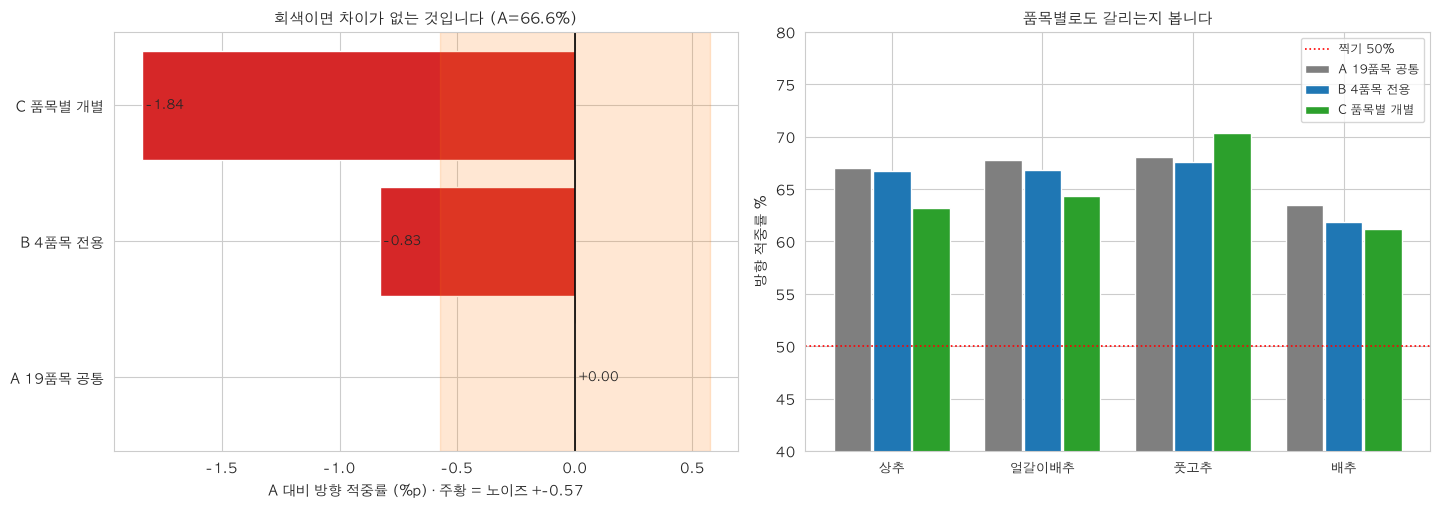

,A 19품목 공통,B 4품목 전용,C 품목별 개별
item,,,
상추,67.0,66.7,63.1
얼갈이배추,67.7,66.8,64.3
풋고추,68.1,67.6,70.4
배추,63.4,61.8,61.1


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2))

ax = axes[0]
diff = cmp["A 대비 %p"]
cols = ["tab:green" if v > FLOOR else "tab:red" if v < -FLOOR else "tab:gray"
        for v in diff]
ax.barh(cmp.index, diff, color=cols)
ax.axvspan(-FLOOR, FLOOR, color="tab:orange", alpha=0.18)
ax.axvline(0, color="black", lw=1.2)
for i, v in enumerate(diff):
    ax.text(v, i, f" {v:+.2f}", va="center", fontsize=9)
ax.set_xlabel(f"A 대비 방향 적중률 (%p) · 주황 = 노이즈 +-{FLOOR:.2f}")
ax.set_title(f"회색이면 차이가 없는 것입니다 (A={cmp.loc['A 19품목 공통','적중률 %']:.1f}%)",
             fontsize=11)

ax = axes[1]
per = pd.DataFrame({n: p.groupby("item").방향맞음.mean() * 100
                    for n, p in preds.items()}).loc[중간지대]
x = np.arange(len(per))
for i, (n, c) in enumerate(zip(preds, ["tab:gray", "tab:blue", "tab:green"])):
    ax.bar(x + (i - 1) * 0.26, per[n], width=0.25, color=c, label=n)
ax.axhline(50, color="red", ls=":", lw=1.2, label="찍기 50%")
ax.set_xticks(x)
ax.set_xticklabels(per.index, fontsize=9.5)
ax.set_ylim(40, 80)
ax.set_ylabel("방향 적중률 %")
ax.set_title("품목별로도 갈리는지 봅니다", fontsize=11)
ax.legend(fontsize=8.5)

plt.tight_layout()
plt.show()
display(per.round(1))

## 5. 운영 지표로 환산

적중률만으로는 판단이 안 됩니다. 14·15·17번이 쌓아온 지표로 바꿔 봅니다.
**출하 전량을 오늘 팔면 1,000만 원**이라고 놓습니다.

In [6]:
rows = []
for name, p in preds.items():
    s = 성적(p)
    넣은비율 = s["더 받은 돈 %"] / s["창고비 한도 %"] if s["창고비 한도 %"] else np.nan
    rows.append({
        "방식": name,
        "창고에 넣은 물건값 (만원)": 1000 * 넣은비율,
        "더 번 돈 (만원)": 1000 * s["더 받은 돈 %"] / 100,
        "넣은 값 대비 %": s["창고비 한도 %"],
        "품목당 연 창고행": s["품목당 연 창고행"],
        "확신한 날 적중률 %": s["확신한 날 적중률 %"],
    })
운영 = pd.DataFrame(rows).set_index("방식")
display(운영.round(1))
print("기준: 15번 확신도 0.20 · 중간지대 4품목 = 넣은 값 대비 16.2%, 17번 연 51.1일")

,창고에 넣은 물건값 (만원),더 번 돈 (만원),넣은 값 대비 %,품목당 연 창고행,확신한 날 적중률 %
방식,,,,,
A 19품목 공통,209.6,33.9,16.2,51.1,77.8
B 4품목 전용,256.7,33.3,13.0,62.6,73.4
C 품목별 개별,394.8,44.0,11.2,96.3,70.2


기준: 15번 확신도 0.20 · 중간지대 4품목 = 넣은 값 대비 16.2%, 17번 연 51.1일


### 창고비가 싸면 순위가 뒤집힙니다

C 는 적중률이 가장 낮은데 **총액으로는 가장 많이 법니다**: 창고에 훨씬 많이
넣기 때문입니다. 대신 창고비도 그만큼 더 듭니다.

창고비를 물건값의 `c%` 라고 놓으면 남는 돈은 **더 번 돈 − 넣은 물건값 × c%**
입니다. 두 방식이 같아지는 `c` 를 구하면 **어느 쪽을 쓸지 가르는 선**이 나옵니다.

C 품목별 개별 와 A 19품목 공통 가 같아지는 창고비: 5.48%
B 4품목 전용 와 A 19품목 공통 가 같아지는 창고비: -1.25%


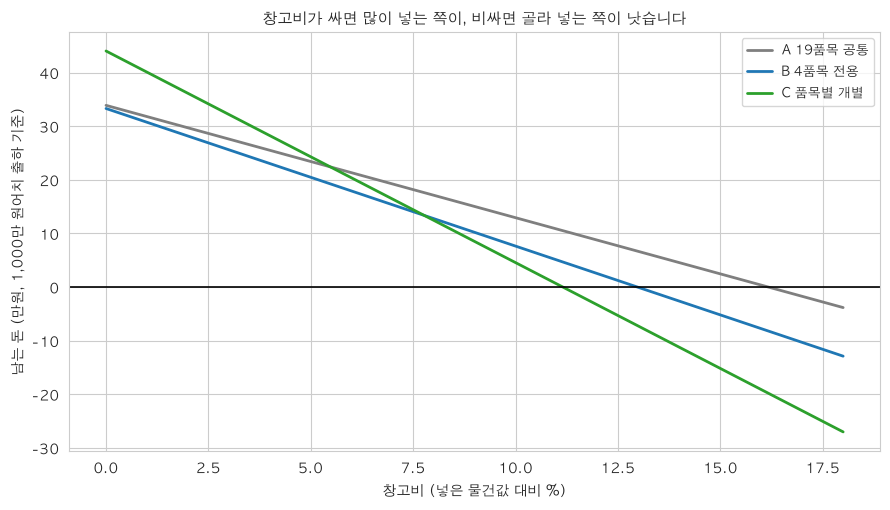

In [7]:
def 남는돈(방식, c):
    row = 운영.loc[방식]
    return row["더 번 돈 (만원)"] - row["창고에 넣은 물건값 (만원)"] * c / 100


쌍 = [("C 품목별 개별", "A 19품목 공통"), ("B 4품목 전용", "A 19품목 공통")]
for x, y in 쌍:
    dg = 운영.loc[x, "더 번 돈 (만원)"] - 운영.loc[y, "더 번 돈 (만원)"]
    ds = 운영.loc[x, "창고에 넣은 물건값 (만원)"] - 운영.loc[y, "창고에 넣은 물건값 (만원)"]
    교차 = dg / ds * 100 if ds else np.nan
    print(f"{x} 와 {y} 가 같아지는 창고비: {교차:.2f}%")

cs = np.linspace(0, 18, 200)
fig, ax = plt.subplots(figsize=(9, 5.2))
for name, col in zip(운영.index, ["tab:gray", "tab:blue", "tab:green"]):
    ax.plot(cs, [남는돈(name, c) for c in cs], lw=2, color=col, label=name)
ax.axhline(0, color="black", lw=1.2)
ax.set_xlabel("창고비 (넣은 물건값 대비 %)")
ax.set_ylabel("남는 돈 (만원, 1,000만 원어치 출하 기준)")
ax.set_title("창고비가 싸면 많이 넣는 쪽이, 비싸면 골라 넣는 쪽이 낫습니다",
             fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6. 결론

### 한 줄 요약

**전용 모델은 더 나쁩니다.** 19품목을 함께 학습하는 현행 방식이 최선이고,
다른 품목들은 방해가 아니라 **도움**이었습니다.

### 가설 판정

| 가설 | 내용 | 결과 | 판정 |
|---|---|---|---|
| **H1** | 4품목만 학습하면 낫다 | **-0.83%p** (노이즈 ±0.57%p) | **반증됨** (오히려 악화) |
| **H2** | 품목별 개별 모델이 낫다 | **-1.84%p** | **반증됨** (더 악화) |
| **H3** | 운영 지표가 개선된다 | 창고비 한도 16.2% → 13.0% / 11.2% | **반증됨** |

| 방식 | 학습 행수 | 적중률 | 확신한 날 적중률 | 창고비 한도 |
|---|---|---|---|---|
| **A 19품목 공통** (현행) | 23,945 | **66.58%** | **77.8%** | **16.2%** |
| B 4품목 전용 | 5,459 | 65.75% | 73.4% | 13.0% |
| C 품목별 개별 | 5,459 | 64.74% | 70.2% | 11.2% |

**세 지표가 같은 순서로 나옵니다.** 학습 데이터를 줄일수록 나빠지고, 품목별로
쪼갤수록 더 나빠집니다. 08번의 짐작("품목이 늘면 계절·명절 구조를 공유해서
배울 표본이 많아진다")이 여기서 확인됐습니다.

### 16번과 어긋나 보이지만 어긋나지 않습니다

| 노트북 | 비교 | 결과 |
|---|---|---|
| 16 | 6품목 학습 → 19품목 학습 | -0.63%p, **노이즈 이내**(차이 없음) |
| 18 | 19품목 학습 → 4품목 학습 | -0.83%p, **노이즈 넘김**(악화) |

16번은 "차이 없음"이었지 "줄이는 게 낫다"가 아니었습니다. 둘을 합치면
**학습 품목을 줄여서 얻을 건 없고 때로 잃는다**가 됩니다.

노이즈 플로어가 16번(1.15%p)보다 여기서 좁은 것(0.57%p)은 **학습셋이 훨씬
크기 때문**입니다: 난수 피처가 23,945행 속에서 덜 흔듭니다.

### 다만 C 는 다른 자리를 차지합니다

C 는 적중률이 가장 낮은데 **총액으로는 가장 많이 법니다.**

| 방식 | 창고에 넣은 물건값 | 더 번 돈 | 넣은 값 대비 | 품목당 연 창고행 |
|---|---|---|---|---|
| A | 209.6만 원 | 33.9만 원 | 16.2% | 51.1일 |
| B | 256.7만 원 | 33.3만 원 | 13.0% | 62.6일 |
| **C** | **394.8만 원** | **44.0만 원** | 11.2% | 96.3일 |

C 는 `item_code` 가 없어 품목별 상수를 못 배우고, 그래서 확률이 0.5 에서 더 멀리
퍼져 확신하는 날이 73% 로 늘어납니다. **많이 넣고 많이 버는 대신 효율이 낮은
지점**입니다.

**창고비가 싸면 C 가 유리합니다.** 두 방식이 같아지는 창고비가 계산됩니다
(위 셀 참조). 그보다 창고비가 싸면 많이 넣는 C, 비싸면 골라 넣는 A 입니다.
**창고비 실측치가 없으면 이 선택도 못 합니다**(다음 할 일 4번).

### 한계

- **품목별 노이즈는 안 쟀습니다.** 풋고추만 C 가 A 보다 높게(70.4% vs 68.1%)
  나왔는데, 품목 하나 기준 노이즈 폭을 모르니 **의미를 부여할 수 없습니다.**
  16·17번 경험상 품목 단위는 1.3~2.8%p 로 넓습니다.
- **하이퍼파라미터를 그대로 썼습니다.** 05번에서 19품목 기준으로 고른 값이라
  4품목 전용 모델에는 안 맞을 수 있습니다. 다만 05번에서 `learning_rate` 외에는
  성능과 무관했으니 크게 달라지진 않을 것으로 봅니다.
- **C 의 확신도는 A 의 확신도와 같은 뜻이 아닙니다.** 확률 분포가 달라
  같은 0.20 이 다른 커버리지(73% vs 37%)를 뜻합니다. 같은 커버리지로 맞춰
  비교하면 결과가 달라질 수 있습니다.

### 다음

1. **현행 방식을 유지합니다.** 전용 모델 시도는 여기서 닫습니다.
2. **창고비 실측치**가 이제 두 가지를 동시에 가릅니다: 전략이 남는지, 그리고
   A 와 C 중 무엇을 쓸지.
3. **C 를 같은 커버리지로 다시 재보는 것**은 남아 있습니다. 지금 비교는
   커버리지가 두 배 차이라 공정하지 않습니다.